# Regenerate Clean Graphs from JSON Results

This notebook reads the `results_phase4.json` file, extracts all evaluation metrics, and creates improved versions of the original plots.  
All graphs are saved in a subdirectory `graphs_from_json`.

In [3]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for clean plots
sns.set_style('whitegrid')
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

# Paths
json_path = '../phase4_results_archive/results_phase4.json'
output_dir = '../phase4_results_archive/graphs_from_json'

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Load data
with open(json_path, 'r') as f:
    data = json.load(f)

## 1. Baseline Comparison – Weighted F1 Scores

C:\Users\vivek\AppData\Local\Temp\ipykernel_10360\3562394021.py:29: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vivek\AppData\Local\Temp\ipykernel_10360\3562394021.py:35: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.savefig(os.path.join(output_dir, 'f1_baseline_comparison.png'), bbox_inches='tight')


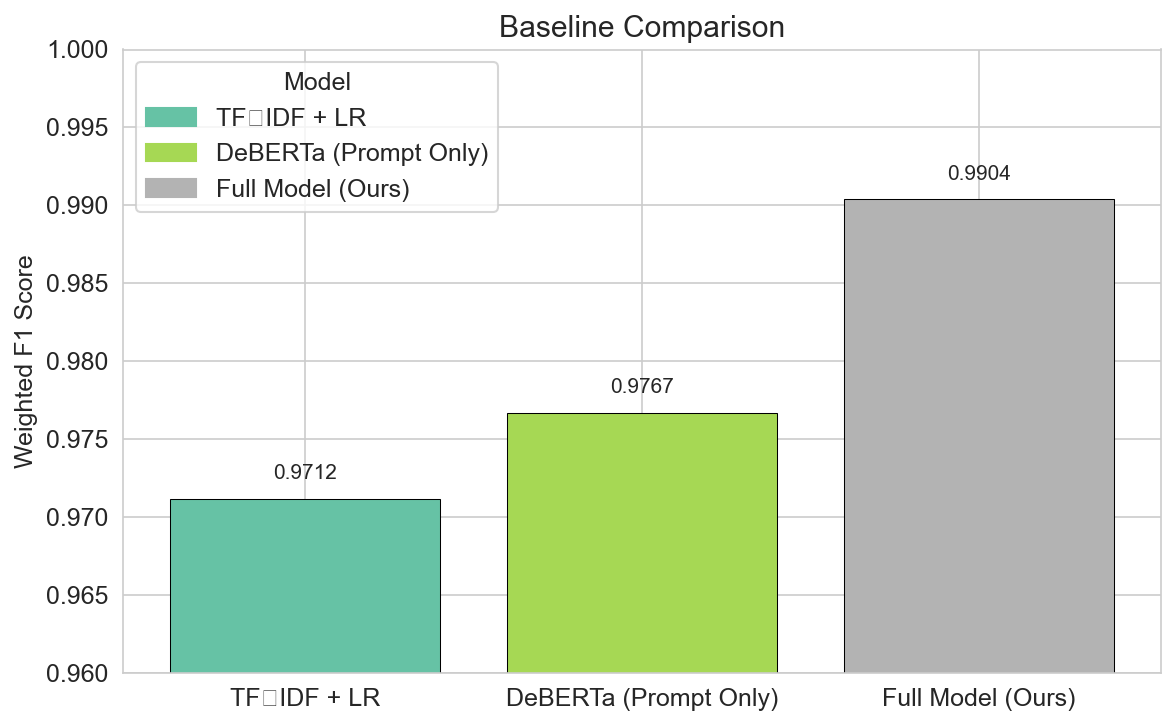

In [14]:
# Extract F1 scores
baseline_models = {
    'TF‑IDF + LR': data['baseline_tfidf_lr']['f1'],
    'DeBERTa (Prompt Only)': data['baseline_deberta_prompt_only']['f1'],
    'Full Model (Ours)': data['full_model']['f1']
}

# Use a distinct color for each model (e.g., from a qualitative colormap)
model_names = list(baseline_models.keys())
model_f1 = list(baseline_models.values())
colors = plt.cm.Set2(np.linspace(0, 1, len(model_names)))  # nice qualitative palette

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, model_f1, color=colors, edgecolor='black', linewidth=0.5)

plt.ylim(0.96, 1.0)
plt.ylabel('Weighted F1 Score')
plt.title('Baseline Comparison')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{height:.4f}', ha='center', va='bottom', fontsize=10)

# Make x‑axis labels horizontal
plt.xticks(rotation=0, ha='center')

plt.tight_layout()

# Add legend in top left corner
legend_handles = [plt.Rectangle((0,0),1,1, color=colors[i]) for i in range(len(model_names))]
plt.legend(legend_handles, model_names, title='Model', loc='upper left')

plt.savefig(os.path.join(output_dir, 'f1_baseline_comparison.png'), bbox_inches='tight')
plt.show()

## 2. Ablation Study – Weighted F1 Scores

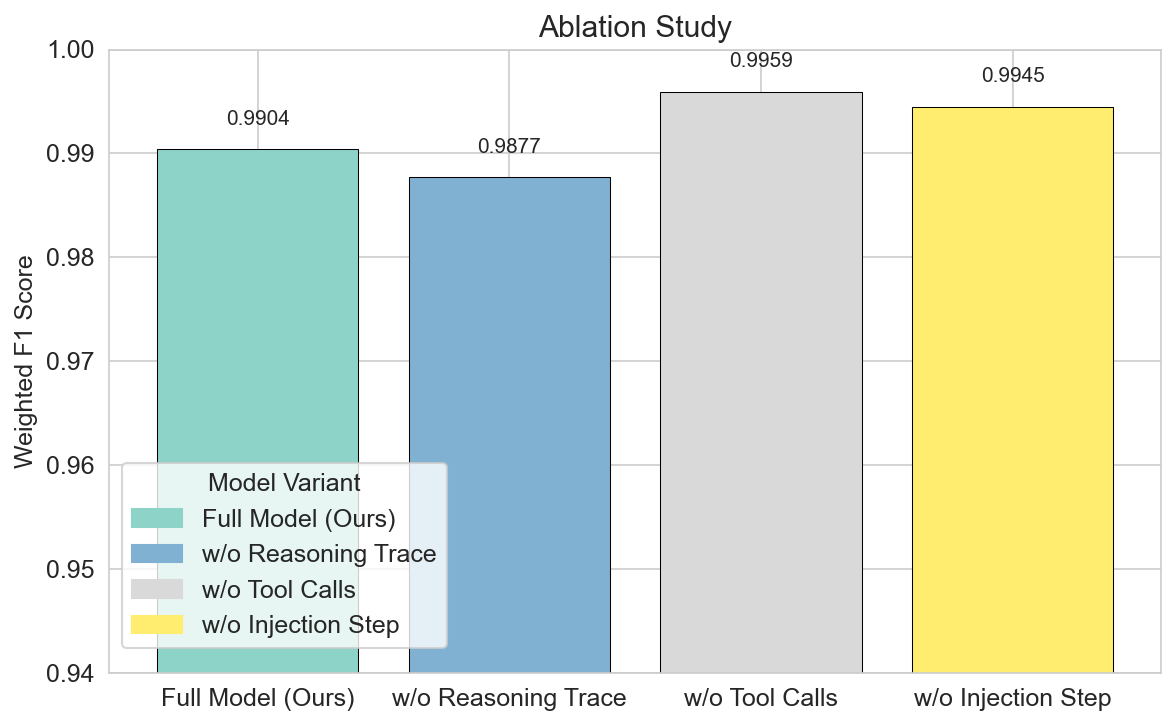

In [10]:
# Extract ablation study data
ablation = data['ablation_study']
ablation_names = list(ablation.keys())
ablation_f1 = [ablation[name]['f1'] for name in ablation_names]

# Use a color palette with distinct colors
colors = plt.cm.Set3(np.linspace(0, 1, len(ablation_names)))

plt.figure(figsize=(8, 5))
bars = plt.bar(ablation_names, ablation_f1, color=colors, edgecolor='black', linewidth=0.5)

# Set y‑axis limits as requested (0.94 to 1)
plt.ylim(0.94, 1.0)
plt.ylabel('Weighted F1 Score')
plt.title('Ablation Study')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{height:.4f}', ha='center', va='bottom', fontsize=10)

# Make x‑axis labels horizontal
plt.xticks(rotation=0, ha='center')
plt.tight_layout()

# Add a legend
legend_handles = [plt.Rectangle((0,0),1,1, color=colors[i]) for i in range(len(ablation_names))]
plt.legend(legend_handles, ablation_names, title='Model Variant', loc='lower left', bbox_to_anchor=(0, 0.02))

# Save and show
plt.savefig(os.path.join(output_dir, 'f1_ablation_study.png'), bbox_inches='tight')
plt.show()

## 3. Confusion Matrices

We plot the confusion matrices for the **Full Model** and **DeBERTa (Prompt Only)** as heatmaps.  
The TF‑IDF + LR matrix is also available and can be added if needed.

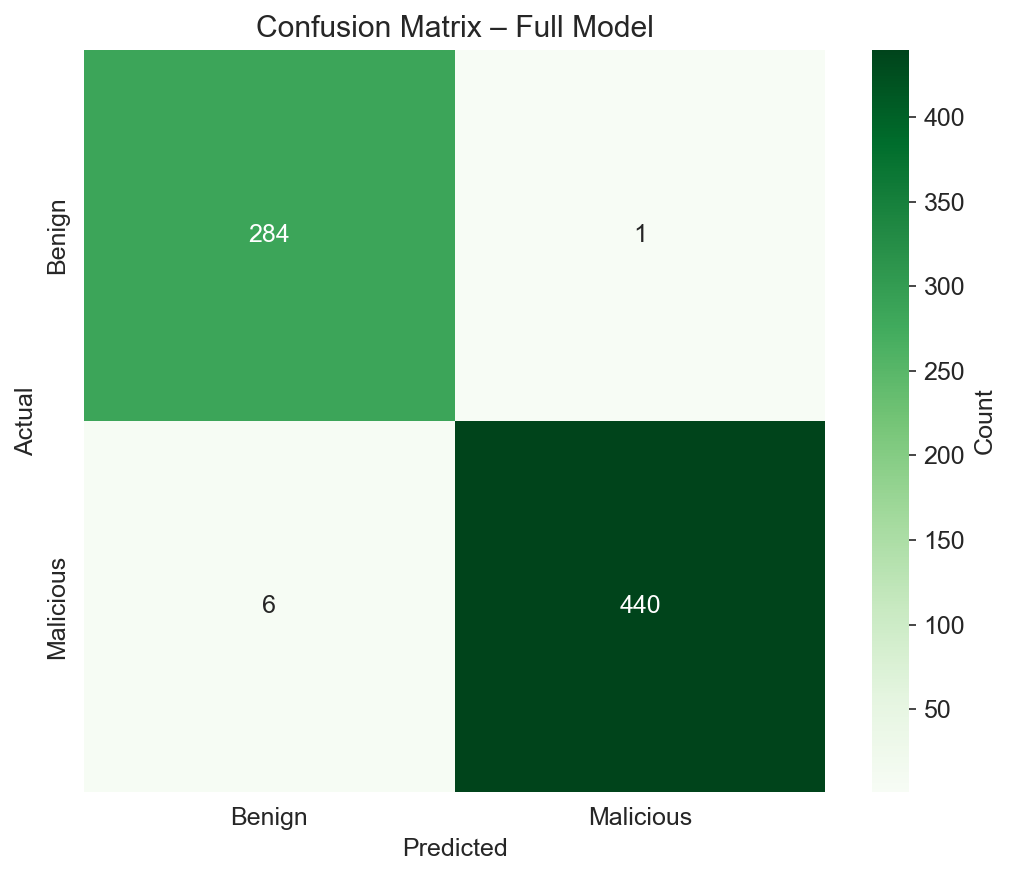

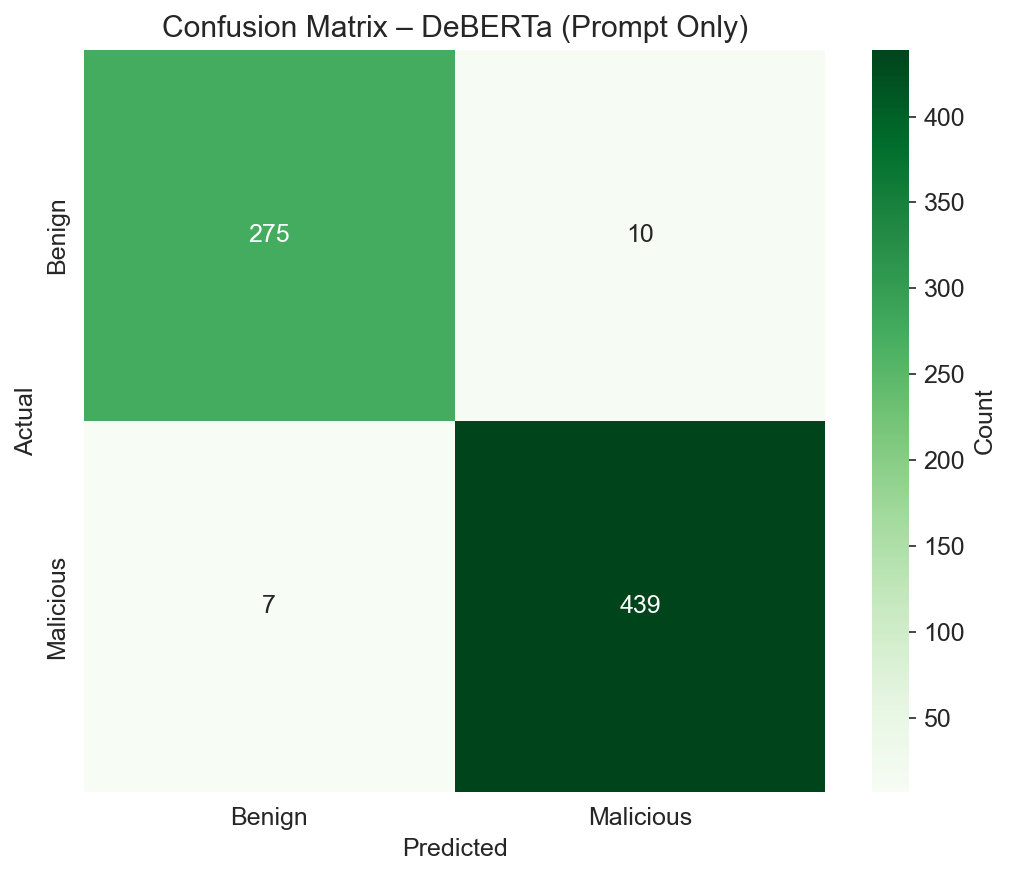

C:\Users\vivek\AppData\Local\Temp\ipykernel_10360\1136489185.py:16: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vivek\AppData\Local\Temp\ipykernel_10360\1136489185.py:17: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.savefig(os.path.join(output_dir, filename), bbox_inches='tight')
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


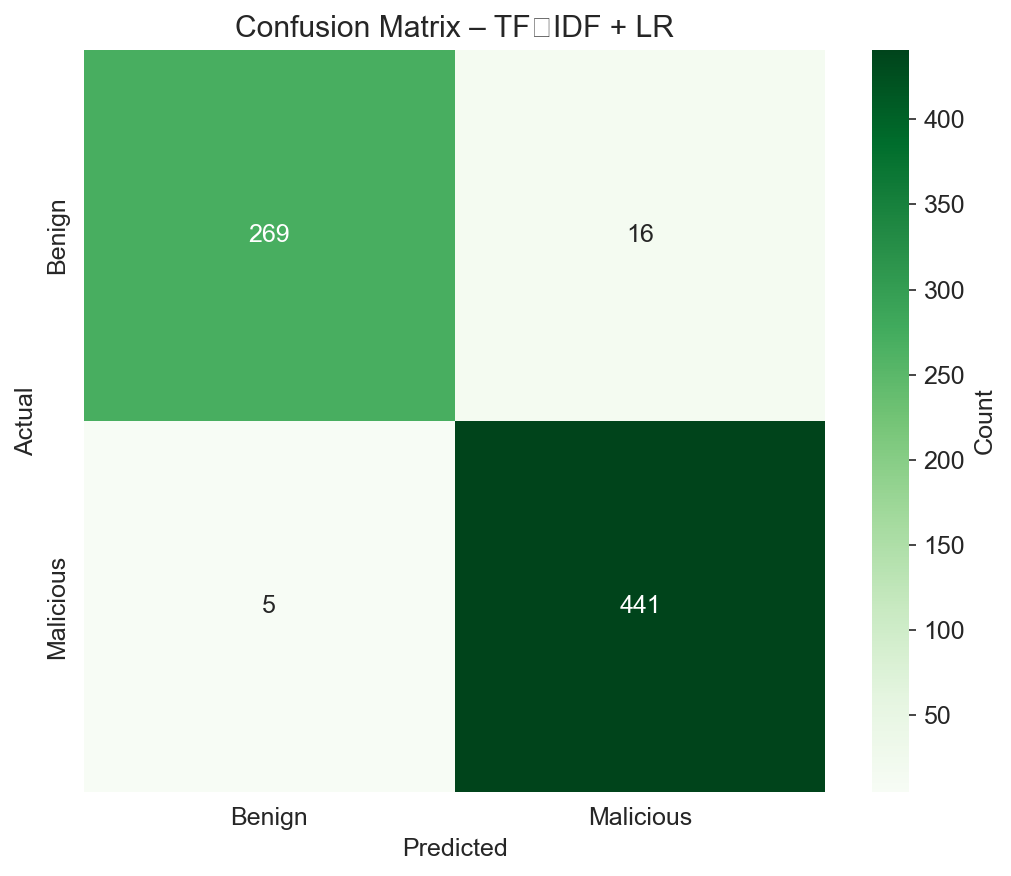

In [23]:
def plot_confusion_matrix(cm, labels, title, filename):
    plt.figure(figsize=(7, 6))  # slightly wider to accommodate colorbar
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens',          # Use a distinct colormap
        xticklabels=labels,
        yticklabels=labels,
        cbar=True,               # Show colorbar on the right
        cbar_kws={'label': 'Count'}
    )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, filename), bbox_inches='tight')
    plt.show()

# Full model
cm_full = data['full_model']['confusion_matrix']
plot_confusion_matrix(cm_full, ['Benign', 'Malicious'], 'Confusion Matrix – Full Model', 'confusion_matrix_full_model.png')

# DeBERTa prompt only
cm_prompt = data['baseline_deberta_prompt_only']['confusion_matrix']
plot_confusion_matrix(cm_prompt, ['Benign', 'Malicious'], 'Confusion Matrix – DeBERTa (Prompt Only)', 'confusion_matrix_prompt_only.png')

# TF‑IDF + LR confusion matrix
cm_tfidf = data['baseline_tfidf_lr']['confusion_matrix']
plot_confusion_matrix(cm_tfidf, ['Benign', 'Malicious'], 'Confusion Matrix – TF‑IDF + LR', 'confusion_matrix_tfidf_lr.png')

## 4. Latency Benchmark

Latency statistics (mean, median, P95, P99) and throughput.

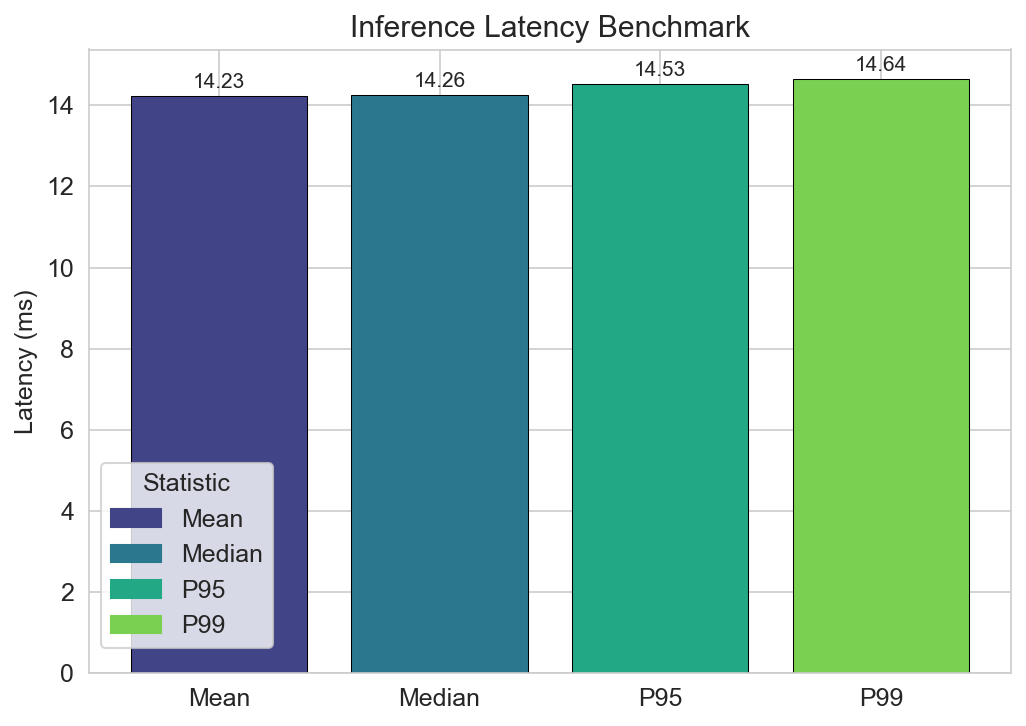

Throughput: 70.3 requests/second


In [13]:
lat = data['latency']
lat_stats = {
    'Mean': lat['mean_ms'],
    'Median': lat['median_ms'],
    'P95': lat['p95_ms'],
    'P99': lat['p99_ms']
}

# Use a distinct color for each bar
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(lat_stats)))

plt.figure(figsize=(7, 5))
bars = plt.bar(lat_stats.keys(), lat_stats.values(), color=colors, edgecolor='black', linewidth=0.5)
plt.ylabel('Latency (ms)')
plt.title('Inference Latency Benchmark')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()

# Add a legend in the lower left corner
legend_handles = [plt.Rectangle((0,0),1,1, color=colors[i]) for i in range(len(lat_stats))]
plt.legend(legend_handles, lat_stats.keys(), title='Statistic', loc='lower left', bbox_to_anchor=(0, 0.02))

plt.savefig(os.path.join(output_dir, 'latency_benchmark.png'), bbox_inches='tight')
plt.show()

print(f"Throughput: {lat['throughput_per_sec']} requests/second")

## 5. ROC / AUC Comparison

The original ROC curves required TPR/FPR data, which are not stored in the JSON.  
We therefore create a bar chart of the available AUC scores as an alternative comparison.

C:\Users\vivek\AppData\Local\Temp\ipykernel_10360\2056495496.py:30: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vivek\AppData\Local\Temp\ipykernel_10360\2056495496.py:36: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.savefig(os.path.join(output_dir, 'auc_comparison.png'), bbox_inches='tight')


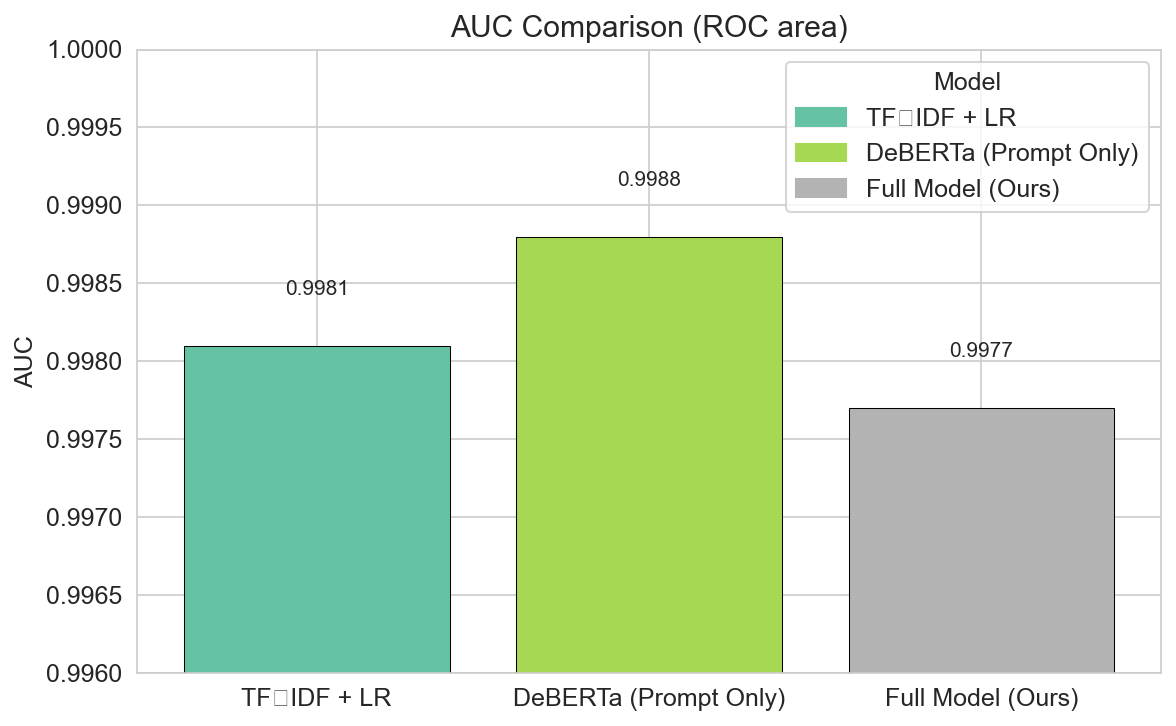

In [16]:
# Collect AUC scores
auc_scores = {
    'TF‑IDF + LR': data['baseline_tfidf_lr']['auc'],
    'DeBERTa (Prompt Only)': data['baseline_deberta_prompt_only']['auc'],
    'Full Model (Ours)': data['full_model']['auc']
}

model_names = list(auc_scores.keys())
model_auc = list(auc_scores.values())

# Use a distinct color for each model
colors = plt.cm.Set2(np.linspace(0, 1, len(model_names)))

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, model_auc, color=colors, edgecolor='black', linewidth=0.5)

plt.ylim(0.996, 1.0)
plt.ylabel('AUC')
plt.title('AUC Comparison (ROC area)')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.0003,
             f'{height:.4f}', ha='center', va='bottom', fontsize=10)

# Make x‑axis labels horizontal
plt.xticks(rotation=0, ha='center')

plt.tight_layout()

# Add legend in top right corner
legend_handles = [plt.Rectangle((0,0),1,1, color=colors[i]) for i in range(len(model_names))]
plt.legend(legend_handles, model_names, title='Model', loc='upper right')

plt.savefig(os.path.join(output_dir, 'auc_comparison.png'), bbox_inches='tight')
plt.show()

## 6. Additional: Full Metrics Table

For completeness, we print the full classification reports.

In [9]:
print("=== Full Model Report ===")
print(data['full_model']['report'])
print("\n=== DeBERTa Prompt Only Report ===")
print(data['baseline_deberta_prompt_only']['report'])
print("\n=== TF‑IDF + LR Report ===")
print(data['baseline_tfidf_lr']['report'])

=== Full Model Report ===
{'benign': {'precision': 0.9793103448275862, 'recall': 0.9964912280701754, 'f1-score': 0.9878260869565217, 'support': 285.0}, 'malicious': {'precision': 0.9977324263038548, 'recall': 0.9865470852017937, 'f1-score': 0.992108229988726, 'support': 446.0}, 'accuracy': 0.9904240766073872, 'macro avg': {'precision': 0.9885213855657204, 'recall': 0.9915191566359846, 'f1-score': 0.989967158472624, 'support': 731.0}, 'weighted avg': {'precision': 0.9905500826366366, 'recall': 0.9904240766073872, 'f1-score': 0.9904387214193987, 'support': 731.0}}

=== DeBERTa Prompt Only Report ===
{'benign': {'precision': 0.975177304964539, 'recall': 0.9649122807017544, 'f1-score': 0.9700176366843033, 'support': 285.0}, 'malicious': {'precision': 0.977728285077951, 'recall': 0.984304932735426, 'f1-score': 0.9810055865921787, 'support': 446.0}, 'accuracy': 0.9767441860465116, 'macro avg': {'precision': 0.9764527950212449, 'recall': 0.9746086067185902, 'f1-score': 0.975511611638241, 'sup